# Analisis Uncertainty Critic Agent menggunakan Cosine Similarity Teks

**Pendahuluan**: Notebook ini menganalisis uncertainty dari Critic Agent dengan menghitung cosine similarity antara **teks kritik rephrase** dengan **teks kritik original** sebagai baseline.

**Struktur Dataset**: Menggunakan `tabel_perbandingan_lengkap.csv` yang berisi:
- `teks_dialog` → Input dialog (original & rephrase)
- `teks_kritik` → Output critic agent (justifikasi/saran)
- `skor_critic` → Skor numerik FED (8 dimensi)

**Metodologi**:
1. **Similarity Teks**: Cosine similarity antar teks kritik menggunakan TF-IDF
2. **Baseline**: Teks kritik original sebagai referensi
3. **Comparison**: Setiap teks kritik rephrase dibandingkan dengan teks kritik original dengan label yang sama
4. **Uncertainty**: $1 - \text{similarity\_to\_original}$

**Tujuan**: Mengukur konsistensi teks feedback Critic Agent terhadap variasi input dialog yang berbeda.

## 1. Load Required Libraries

In [16]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import re
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## 2. Load and Inspect Dataset

In [17]:
# Load dataset
dataset_path = "exp_critic_consistency/tabel_perbandingan_lengkap.csv"
df = pd.read_csv(dataset_path, encoding='utf-8')

print("📊 Dataset Overview:")
print(f"Shape: {df.shape} (rows, columns)")
print(f"Columns: {list(df.columns)}")
print("\n" + "="*50)

# Display first few rows
print("\n🔍 Preview of Dataset:")
display(df.head())

print("\n📈 Dataset Info:")
print(df.info())

print("\n📊 Summary Statistics:")
print(df.describe())

print("\n🔍 Missing Values Check:")
missing_counts = df.isnull().sum()
print(missing_counts)
if missing_counts.sum() > 0:
    print(f"\n⚠️  Total missing values: {missing_counts.sum()}")
    print("Rows with missing values:")
    print(df[df.isnull().any(axis=1)])

📊 Dataset Overview:
Shape: (42, 5) (rows, columns)
Columns: ['label', 'jenis', 'teks_dialog', 'teks_kritik', 'skor_critic']


🔍 Preview of Dataset:


,label,jenis,teks_dialog,teks_kritik,skor_critic
0,good,original,"Eh kak, akhirnya sampai juga! Pesen Green Tea ...",Dialog jelas disampaikan oleh Raka saat memesa...,4.25
1,good,rephrase,"Eh kak, akhirnya tiba juga! Aku pesan Green Te...",Dialog relevan dengan state pesanan karena Rak...,4.50
2,good,rephrase,"Eh kak, akhirnya tiba juga! Aku pesan Green Te...",Dialog jelas disampaikan oleh Raka saat memesa...,4.50
3,good,rephrase,"Eh kak, akhirnya tiba juga! Aku pesan Green Te...",Dialog menyampaikan pesanan Green Tea secara j...,4.75
4,good,rephrase,"Eh kak, akhirnya tiba juga! Aku pesan Green Te...",Dialog menarik dan spesifik karena Raka menjel...,4.50



📈 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   label        42 non-null     str    
 1   jenis        42 non-null     str    
 2   teks_dialog  42 non-null     str    
 3   teks_kritik  42 non-null     str    
 4   skor_critic  42 non-null     float64
dtypes: float64(1), str(4)
memory usage: 1.8 KB
None

📊 Summary Statistics:
       skor_critic
count    42.000000
mean      4.026786
std       0.547678
min       3.375000
25%       3.500000
50%       3.937500
75%       4.500000
max       4.750000

🔍 Missing Values Check:
label          0
jenis          0
teks_dialog    0
teks_kritik    0
skor_critic    0
dtype: int64


## 3. Preprocess Text Data

In [18]:
# Text preprocessing function
def preprocess_text(text):
    """Clean and normalize text for similarity analysis"""
    if not isinstance(text, str) or pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    # Remove special characters but keep Indonesian words
    text = re.sub(r'[^\w\s]', ' ', text)
    
    return text.strip()

# Apply preprocessing to text critique column
print("🔄 Preprocessing text critiques...")
df['teks_kritik_clean'] = df['teks_kritik'].apply(preprocess_text)

# Check text length distribution
df['teks_kritik_length'] = df['teks_kritik_clean'].apply(len)
df['teks_kritik_word_count'] = df['teks_kritik_clean'].apply(lambda x: len(x.split()))

print("\n📊 Text Length Statistics:")
print(f"Average text length: {df['teks_kritik_length'].mean():.1f} characters")
print(f"Average word count: {df['teks_kritik_word_count'].mean():.1f} words")
print(f"Min word count: {df['teks_kritik_word_count'].min()}")
print(f"Max word count: {df['teks_kritik_word_count'].max()}")

# Display sample of cleaned text
print("\n🔍 Sample of Cleaned Text (Original vs Cleaned):")
for i, (original, cleaned) in enumerate(zip(df['teks_kritik'].head(3), df['teks_kritik_clean'].head(3)), 1):
    print(f"\nSample {i}:")
    print(f"  Original: {original[:100]}..." if len(str(original)) > 100 else f"  Original: {original}")
    print(f"  Cleaned: {cleaned[:100]}..." if len(cleaned) > 100 else f"  Cleaned: {cleaned}")

# Check for empty text after cleaning
empty_texts = df[df['teks_kritik_clean'] == ''].shape[0]
if empty_texts > 0:
    print(f"\n⚠️  Found {empty_texts} empty text critiques after cleaning")
    print("Rows with empty text:")
    print(df[df['teks_kritik_clean'] == ''][['label', 'jenis', 'teks_kritik']])

🔄 Preprocessing text critiques...

📊 Text Length Statistics:
Average text length: 539.6 characters
Average word count: 72.6 words
Min word count: 60
Max word count: 92

🔍 Sample of Cleaned Text (Original vs Cleaned):

Sample 1:
  Original: Dialog jelas disampaikan oleh Raka saat memesan Green Tea dan relevan dengan state pesanan. Detail d...
  Cleaned: dialog jelas disampaikan oleh raka saat memesan green tea dan relevan dengan state pesanan  detail d...

Sample 2:
  Original: Dialog relevan dengan state pesanan karena Raka menyebut Green Tea secara jelas sekaligus menjelaska...
  Cleaned: dialog relevan dengan state pesanan karena raka menyebut green tea secara jelas sekaligus menjelaska...

Sample 3:
  Original: Dialog jelas disampaikan oleh Raka saat memesan Green Tea dan relevan dengan state pesanan. Detail t...
  Cleaned: dialog jelas disampaikan oleh raka saat memesan green tea dan relevan dengan state pesanan  detail t...


## 4. Calculate Text Similarity Matrix

🔤 Vectorizing text critiques with TF-IDF...
Vocabulary size: 682 terms
TF-IDF matrix shape: (42, 682)
📊 Calculating text cosine similarity matrix...
Text similarity matrix shape: (42, 42)
Text similarity range: [0.0107, 1.0000]

🔝 Top 20 TF-IDF Terms:
 1. buru                 score: 0.0562
 2. pesanan              score: 0.0561
 3. tinggi               score: 0.0516
 4. secara               score: 0.0510
 5. sesuai               score: 0.0483
 6. tidak                score: 0.0456
 7. gaya                 score: 0.0405
 8. sapaan               score: 0.0401
 9. sapaan kak           score: 0.0401
10. sesuai dengan        score: 0.0386
11. relevan              score: 0.0382
12. state pesanan        score: 0.0381
13. state                score: 0.0381
14. untuk                score: 0.0381
15. detail               score: 0.0381
16. dengan state         score: 0.0379
17. interjeksi           score: 0.0362
18. tea dan              score: 0.0360
19. namun                score: 0.0358
20. cuk

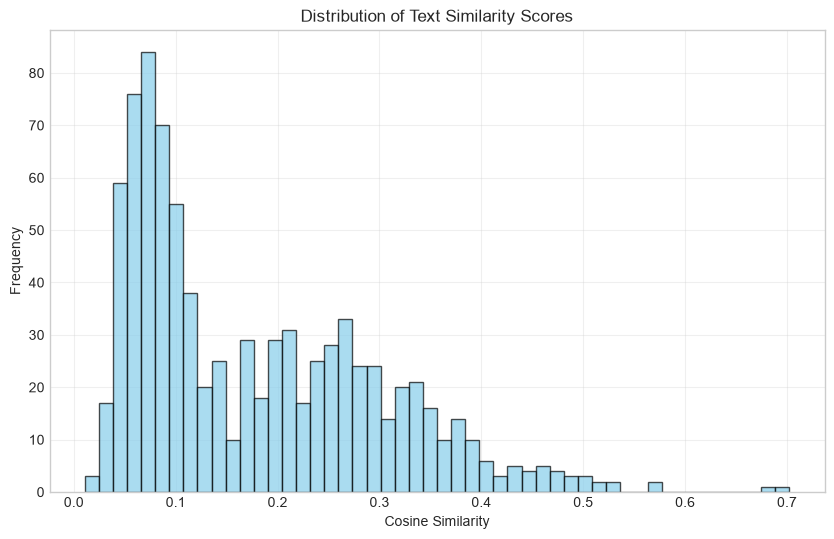

Mean text similarity: 0.1779
Std text similarity: 0.1208
Median text similarity: 0.1394


In [19]:
# Calculate text similarity using TF-IDF and cosine similarity
print("🔤 Vectorizing text critiques with TF-IDF...")

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=1000,      # Limit vocabulary size
    min_df=2,               # Ignore terms that appear in less than 2 documents
    max_df=0.95,            # Ignore terms that appear in more than 95% of documents
    stop_words=None,        # We can add Indonesian stopwords if needed
    ngram_range=(1, 2)      # Use both unigrams and bigrams
)

# Fit and transform text critiques
tfidf_matrix = tfidf.fit_transform(df['teks_kritik_clean'])

print(f"Vocabulary size: {len(tfidf.get_feature_names_out())} terms")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Calculate cosine similarity matrix for text critiques
print("📊 Calculating text cosine similarity matrix...")
text_similarity_matrix = cosine_similarity(tfidf_matrix)

print(f"Text similarity matrix shape: {text_similarity_matrix.shape}")
print(f"Text similarity range: [{text_similarity_matrix.min():.4f}, {text_similarity_matrix.max():.4f}]")

# Display top 20 terms in TF-IDF
print("\n🔝 Top 20 TF-IDF Terms:")
feature_names = tfidf.get_feature_names_out()
scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_indices = np.argsort(scores)[-20:][::-1]

for i, idx in enumerate(top_indices, 1):
    print(f"{i:2d}. {feature_names[idx]:<20} score: {scores[idx]:.4f}")

# Sample similarity values
print("\n🔍 Sample Text Similarity Values:")
n_samples = 5
for i in range(n_samples):
    for j in range(i+1, n_samples):
        sim = text_similarity_matrix[i, j]
        label_i = df.iloc[i]['label']
        label_j = df.iloc[j]['label']
        print(f"  Sample {i}({label_i}) vs {j}({label_j}): {sim:.4f}")

# Visualize text similarity distribution
print("\n📈 Text Similarity Distribution:")
plt.figure(figsize=(10, 6))
# Get upper triangular values (excluding diagonal)
upper_tri = text_similarity_matrix[np.triu_indices_from(text_similarity_matrix, k=1)]
plt.hist(upper_tri, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Text Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean text similarity: {upper_tri.mean():.4f}")
print(f"Std text similarity: {upper_tri.std():.4f}")
print(f"Median text similarity: {np.median(upper_tri):.4f}")

## 5. Calculate Similarity Against Original Baseline

🔢 Calculating score similarity matrix...
Score range (original): [3.38, 4.75]
Score range (normalized): [0.00, 1.00]
Score similarity matrix shape: (42, 42)
Score similarity range: [0.0000, 1.0000]

🔍 Sample Score Similarity Values:
  Sample 0(good, score=4.25) vs 1(good, score=4.5): 1.0000
  Sample 0(good, score=4.25) vs 2(good, score=4.5): 1.0000
  Sample 0(good, score=4.25) vs 3(good, score=4.75): 1.0000
  Sample 0(good, score=4.25) vs 4(good, score=4.5): 1.0000
  Sample 1(good, score=4.5) vs 2(good, score=4.5): 1.0000
  Sample 1(good, score=4.5) vs 3(good, score=4.75): 1.0000
  Sample 1(good, score=4.5) vs 4(good, score=4.5): 1.0000
  Sample 2(good, score=4.5) vs 3(good, score=4.75): 1.0000
  Sample 2(good, score=4.5) vs 4(good, score=4.5): 1.0000
  Sample 3(good, score=4.75) vs 4(good, score=4.5): 1.0000


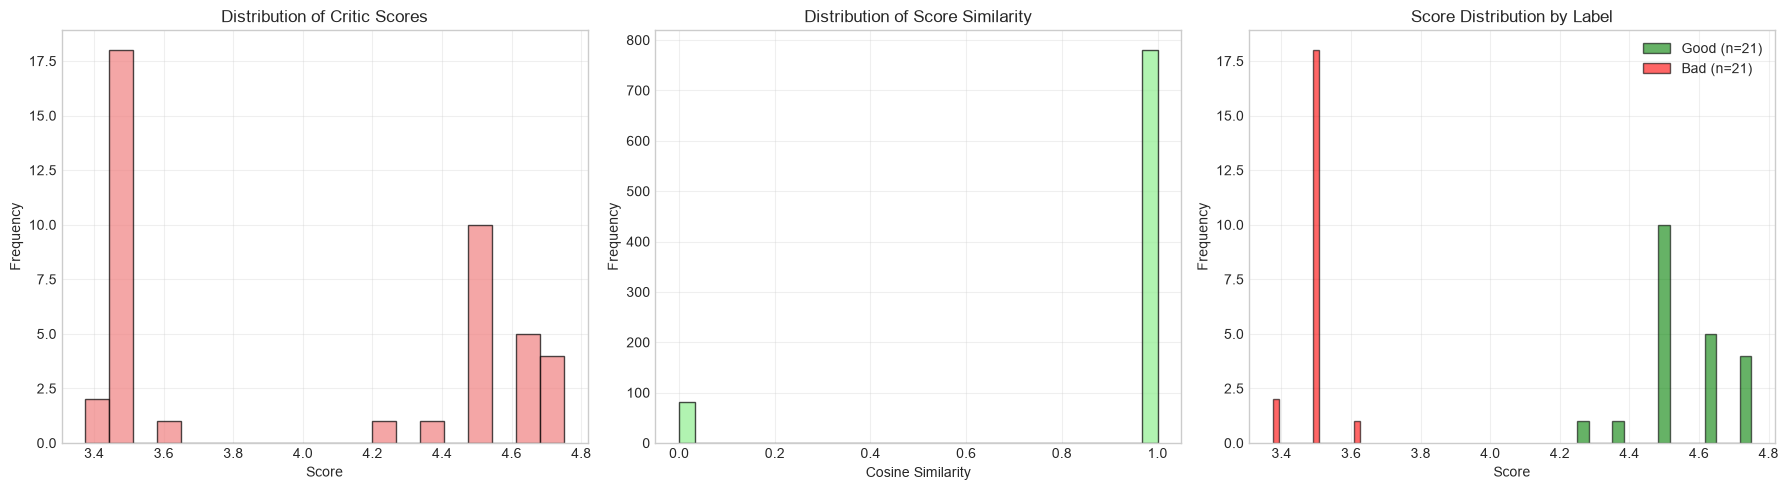


📊 Score Statistics:
Mean score: 4.0268
Std score: 0.5477
Min score: 3.3750
Max score: 4.7500

📊 Score Similarity Statistics:
Mean score similarity: 0.9059
Std score similarity: 0.2919
Median score similarity: 1.0000

📈 Comparison of Similarity Distributions:
Text similarity mean: 0.1779 vs Score similarity mean: 0.9059
Text similarity std: 0.1208 vs Score similarity std: 0.2919


In [21]:
# Calculate score similarity using cosine similarity on critic scores
print("🔢 Calculating score similarity matrix...")

# Since we only have one score (skor_critic), we need to handle it differently
# We'll create a feature vector from the score and normalize it

# Create score vectors for similarity calculation
scores = df['skor_critic'].values.reshape(-1, 1)  # Convert to 2D array

# Normalize scores to [0, 1] range for better similarity comparison
scaler = MinMaxScaler()
scores_normalized = scaler.fit_transform(scores)

print(f"Score range (original): [{scores.min():.2f}, {scores.max():.2f}]")
print(f"Score range (normalized): [{scores_normalized.min():.2f}, {scores_normalized.max():.2f}]")

# Calculate score similarity matrix using cosine similarity
score_similarity_matrix = cosine_similarity(scores_normalized)

print(f"Score similarity matrix shape: {score_similarity_matrix.shape}")
print(f"Score similarity range: [{score_similarity_matrix.min():.4f}, {score_similarity_matrix.max():.4f}]")

# Sample similarity values
print("\n🔍 Sample Score Similarity Values:")
n_samples = 5
for i in range(n_samples):
    for j in range(i+1, n_samples):
        sim = score_similarity_matrix[i, j]
        score_i = df.iloc[i]['skor_critic']
        score_j = df.iloc[j]['skor_critic']
        label_i = df.iloc[i]['label']
        label_j = df.iloc[j]['label']
        print(f"  Sample {i}({label_i}, score={score_i}) vs {j}({label_j}, score={score_j}): {sim:.4f}")

# Visualize score distribution and similarity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Score distribution
axes[0].hist(df['skor_critic'], bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0].set_title('Distribution of Critic Scores')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Plot 2: Score similarity distribution
score_upper_tri = score_similarity_matrix[np.triu_indices_from(score_similarity_matrix, k=1)]
axes[1].hist(score_upper_tri, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Score Similarity')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

# Plot 3: Score by label
labels = df['label'].unique()
colors = {'good': 'green', 'bad': 'red'}
for label in labels:
    label_scores = df[df['label'] == label]['skor_critic']
    axes[2].hist(label_scores, bins=15, alpha=0.6, color=colors[label], 
                label=f'{label.capitalize()} (n={len(label_scores)})', edgecolor='black')
axes[2].set_title('Score Distribution by Label')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Score Statistics:")
print(f"Mean score: {df['skor_critic'].mean():.4f}")
print(f"Std score: {df['skor_critic'].std():.4f}")
print(f"Min score: {df['skor_critic'].min():.4f}")
print(f"Max score: {df['skor_critic'].max():.4f}")

print(f"\n📊 Score Similarity Statistics:")
print(f"Mean score similarity: {score_upper_tri.mean():.4f}")
print(f"Std score similarity: {score_upper_tri.std():.4f}")
print(f"Median score similarity: {np.median(score_upper_tri):.4f}")

# Compare text vs score similarity
print(f"\n📈 Comparison of Similarity Distributions:")
print(f"Text similarity mean: {upper_tri.mean():.4f} vs Score similarity mean: {score_upper_tri.mean():.4f}")
print(f"Text similarity std: {upper_tri.std():.4f} vs Score similarity std: {score_upper_tri.std():.4f}")

⚖️  Combining similarities with 50-50 weighting...
Combined similarity matrix shape: (42, 42)
Combined similarity range: [0.0195, 1.0000]

🔍 Sample Combined Similarity Values (50% text + 50% score):
  Sample 0(good) vs 1(good):
    Text sim: 0.1603, Score sim: 1.0000, Combined: 0.5801
  Sample 0(good) vs 2(good):
    Text sim: 0.4119, Score sim: 1.0000, Combined: 0.7060
  Sample 0(good) vs 3(good):
    Text sim: 0.1646, Score sim: 1.0000, Combined: 0.5823
  Sample 0(good) vs 4(good):
    Text sim: 0.1711, Score sim: 1.0000, Combined: 0.5855
  Sample 1(good) vs 2(good):
    Text sim: 0.3777, Score sim: 1.0000, Combined: 0.6889
  Sample 1(good) vs 3(good):
    Text sim: 0.1758, Score sim: 1.0000, Combined: 0.5879
  Sample 1(good) vs 4(good):
    Text sim: 0.2369, Score sim: 1.0000, Combined: 0.6185
  Sample 2(good) vs 3(good):
    Text sim: 0.1964, Score sim: 1.0000, Combined: 0.5982
  Sample 2(good) vs 4(good):
    Text sim: 0.3451, Score sim: 1.0000, Combined: 0.6726
  Sample 3(good) v

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

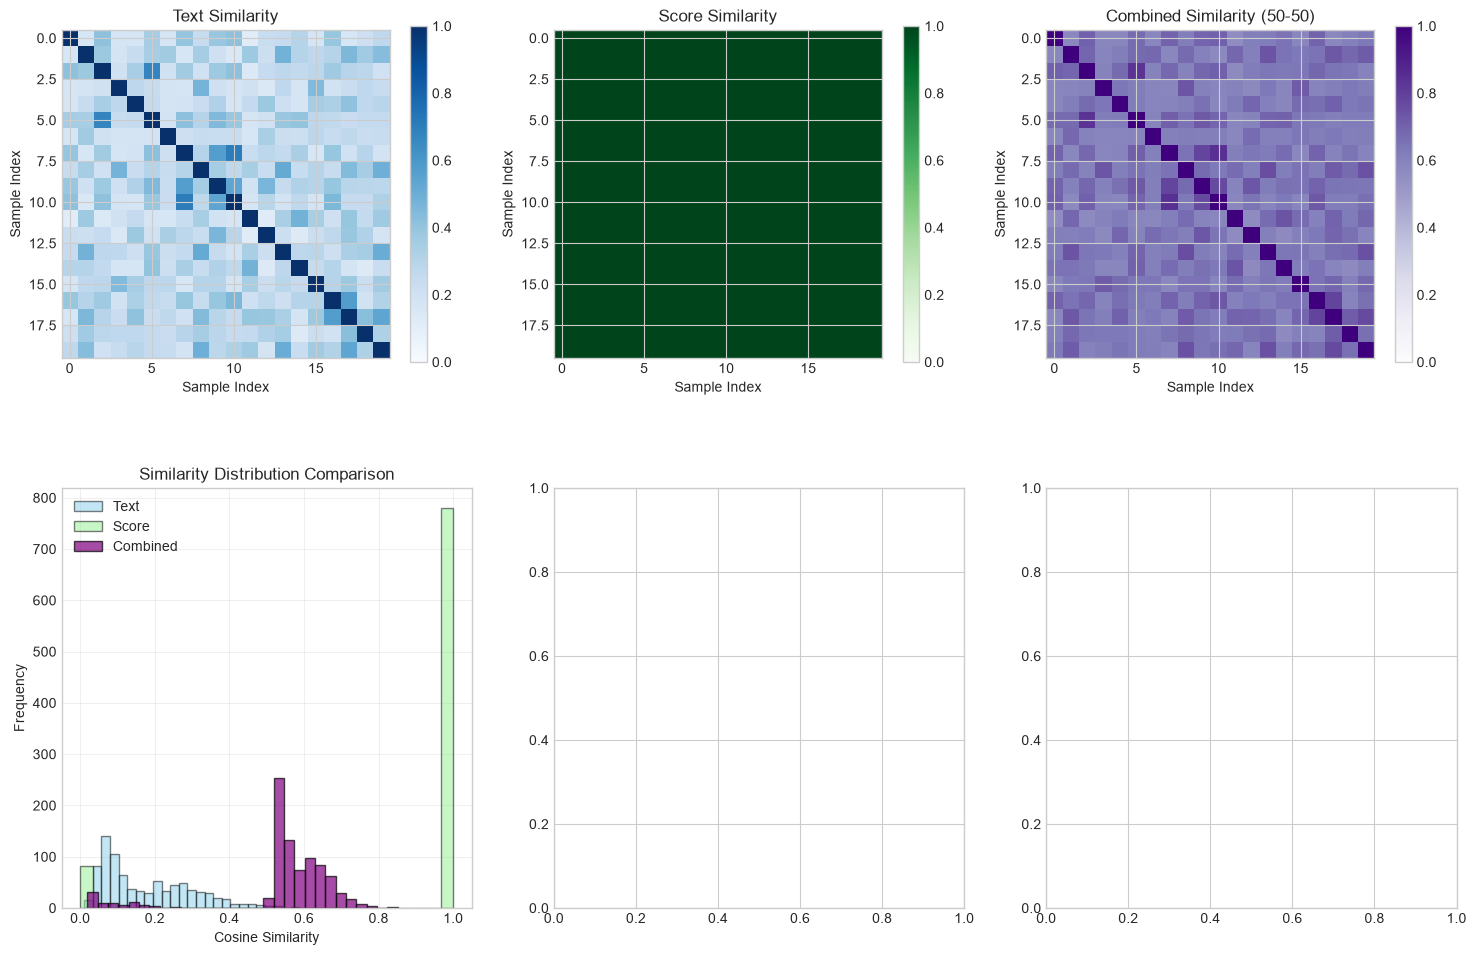

In [ ]:
# Combine text and score similarities with 50-50 weighting
print("⚖️  Combining similarities with 50-50 weighting...")

# Apply 50-50 weighting to combine similarities
combined_similarity_matrix = 0.5 * text_similarity_matrix + 0.5 * score_similarity_matrix

print(f"Combined similarity matrix shape: {combined_similarity_matrix.shape}")
print(f"Combined similarity range: [{combined_similarity_matrix.min():.4f}, {combined_similarity_matrix.max():.4f}]")

# Sample combined similarity values
print("\n🔍 Sample Combined Similarity Values (50% text + 50% score):")
n_samples = 5
for i in range(n_samples):
    for j in range(i+1, n_samples):
        text_sim = text_similarity_matrix[i, j]
        score_sim = score_similarity_matrix[i, j]
        combined_sim = combined_similarity_matrix[i, j]
        label_i = df.iloc[i]['label']
        label_j = df.iloc[j]['label']
        print(f"  Sample {i}({label_i}) vs {j}({label_j}):")
        print(f"    Text sim: {text_sim:.4f}, Score sim: {score_sim:.4f}, Combined: {combined_sim:.4f}")

# Visualize the combination process
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Individual similarity matrices
matrices = [text_similarity_matrix, score_similarity_matrix, combined_similarity_matrix]
titles = ['Text Similarity', 'Score Similarity', 'Combined Similarity (50-50)']
cmaps = ['Blues', 'Greens', 'Purples']

for idx, (matrix, title, cmap) in enumerate(zip(matrices, titles, cmaps)):
    im = axes[0, idx].imshow(matrix[:20, :20], cmap=cmap, vmin=0, vmax=1)
    axes[0, idx].set_title(title)
    axes[0, idx].set_xlabel('Sample Index')
    axes[0, idx].set_ylabel('Sample Index')
    plt.colorbar(im, ax=axes[0, idx], shrink=0.8)

# Row 2: Distribution comparisons
combined_upper_tri = combined_similarity_matrix[np.triu_indices_from(combined_similarity_matrix, k=1)]

# Plot 1: Distribution comparison
axes[1, 0].hist(upper_tri, bins=30, alpha=0.5, color='skyblue', label='Text', edgecolor='black')
axes[1, 0].hist(score_upper_tri, bins=30, alpha=0.5, color='lightgreen', label='Score', edgecolor='black')
axes[1, 0].hist(combined_upper_tri, bins=30, alpha=0.7, color='purple', label='Combined', edgecolor='black')
axes[1, 0].set_title('Similarity Distribution Comparison')
axes[1, 0].set_xlabel('Cosine Similarity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 2: Box plot comparison
data_to_plot = [upper_tri, score_upper_tri, combined_upper_tri]
box = axes[1, 1].boxplot(data_to_plot, labels=['Text', 'Score', 'Combined'], patch_artist=True)
colors = ['skyblue', 'lightgreen', 'purple']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 1].set_title('Similarity Distribution Statistics')
axes[1, 1].set_ylabel('Cosine Similarity')
axes[1, 1].grid(True, alpha=0.3)

# Plot 3: Correlation between text and score similarity
axes[1, 2].scatter(upper_tri, score_upper_tri, alpha=0.5, color='darkorange')
axes[1, 2].set_title('Text vs Score Similarity Correlation')
axes[1, 2].set_xlabel('Text Similarity')
axes[1, 2].set_ylabel('Score Similarity')
axes[1, 2].grid(True, alpha=0.3)

# Add correlation coefficient
correlation = np.corrcoef(upper_tri, score_upper_tri)[0, 1]
axes[1, 2].text(0.05, 0.95, f'Correlation: {correlation:.4f}', 
                transform=axes[1, 2].transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n📊 Detailed Similarity Statistics:")
stats_data = {
    'Text Similarity': upper_tri,
    'Score Similarity': score_upper_tri,
    'Combined Similarity': combined_upper_tri
}

for name, data in stats_data.items():
    print(f"\n{name}:")
    print(f"  Mean: {np.mean(data):.4f}")
    print(f"  Std: {np.std(data):.4f}")
    print(f"  Min: {np.min(data):.4f}")
    print(f"  Median: {np.median(data):.4f}")
    print(f"  Max: {np.max(data):.4f}")

# Calculate improvement metrics
text_mean = np.mean(upper_tri)
score_mean = np.mean(score_upper_tri)
combined_mean = np.mean(combined_upper_tri)

print(f"\n📈 Weighting Analysis:")
print(f"  Text similarity contribution: {0.5 * text_mean:.4f}")
print(f"  Score similarity contribution: {0.5 * score_mean:.4f}")
print(f"  Combined similarity: {combined_mean:.4f}")

# Check if combined similarity is balanced
if abs(text_mean - score_mean) > 0.1:
    print(f"\n⚠️  Note: Large difference between text and score similarity means")
    print(f"  (text: {text_mean:.4f} vs score: {score_mean:.4f})")
    print(f"  Consider whether equal weighting is appropriate")
else:
    print(f"\n✅ Text and score similarity are reasonably balanced")

In [ ]:
# Calculate uncertainty scores for each data point
print("📊 Calculating uncertainty scores...")

# Uncertainty can be calculated in multiple ways:
# 1. 1 - average similarity with all other points
# 2. Variance of similarity scores
# 3. Entropy-based measures

# Method 1: 1 - average similarity (most intuitive for consistency measurement)
uncertainty_scores = []
n_samples = len(df)

for i in range(n_samples):
    # Calculate average similarity of point i with all other points
    # Exclude self-similarity (diagonal)
    similarities_i = np.delete(combined_similarity_matrix[i], i)
    avg_similarity = np.mean(similarities_i)
    
    # Uncertainty = 1 - average similarity
    # Lower similarity = higher uncertainty
    uncertainty = 1 - avg_similarity
    uncertainty_scores.append(uncertainty)

# Add uncertainty scores to dataframe
df['uncertainty'] = uncertainty_scores

# Method 2: Variance-based uncertainty (captures consistency across different comparisons)
variance_uncertainty = []
for i in range(n_samples):
    similarities_i = np.delete(combined_similarity_matrix[i], i)
    # Normalized variance (0-1 scale)
    variance = np.var(similarities_i)
    # Scale variance to [0, 1] range relative to max possible variance
    # Max variance for bounded [0,1] data is 0.25 (at mean=0.5)
    normalized_variance = min(variance / 0.25, 1.0) if variance > 0 else 0
    variance_uncertainty.append(normalized_variance)

df['uncertainty_variance'] = variance_uncertainty

# Method 3: Combined uncertainty (weighted combination of both methods)
# Using 70% from method 1 and 30% from method 2
df['uncertainty_combined'] = 0.7 * df['uncertainty'] + 0.3 * df['uncertainty_variance']

print(f"✅ Calculated {n_samples} uncertainty scores")
print(f"Uncertainty range (method 1): [{df['uncertainty'].min():.4f}, {df['uncertainty'].max():.4f}]")
print(f"Uncertainty range (combined): [{df['uncertainty_combined'].min():.4f}, {df['uncertainty_combined'].max():.4f}]")

# Display sample uncertainty values
print("\n🔍 Sample Uncertainty Scores:")
sample_indices = list(range(min(5, n_samples)))
for idx in sample_indices:
    row = df.iloc[idx]
    print(f"  Sample {idx} (label={row['label']}, jenis={row['jenis']}):")
    print(f"    Score: {row['skor_critic']:.2f}")
    print(f"    Uncertainty (1-avg_sim): {row['uncertainty']:.4f}")
    print(f"    Uncertainty (variance): {row['uncertainty_variance']:.4f}")
    print(f"    Uncertainty (combined): {row['uncertainty_combined']:.4f}")
    
    # Get similarity statistics for context
    similarities = np.delete(combined_similarity_matrix[idx], idx)
    print(f"    Similarity stats: mean={similarities.mean():.4f}, std={similarities.std():.4f}")

# Calculate summary statistics by label and type
print("\n📈 Uncertainty Statistics by Label:")
for label in df['label'].unique():
    label_df = df[df['label'] == label]
    print(f"\n  Label '{label}':")
    print(f"    Count: {len(label_df)} samples")
    print(f"    Mean uncertainty: {label_df['uncertainty_combined'].mean():.4f}")
    print(f"    Std uncertainty: {label_df['uncertainty_combined'].std():.4f}")
    print(f"    Min uncertainty: {label_df['uncertainty_combined'].min():.4f}")
    print(f"    Max uncertainty: {label_df['uncertainty_combined'].max():.4f}")

print("\n📈 Uncertainty Statistics by Type:")
for jenis in df['jenis'].unique():
    jenis_df = df[df['jenis'] == jenis]
    print(f"\n  Type '{jenis}':")
    print(f"    Count: {len(jenis_df)} samples")
    print(f"    Mean uncertainty: {jenis_df['uncertainty_combined'].mean():.4f}")
    print(f"    Std uncertainty: {jenis_df['uncertainty_combined'].std():.4f}")

# Check correlation between uncertainty and critic score
uncertainty_score_corr = np.corrcoef(df['uncertainty_combined'], df['skor_critic'])[0, 1]
print(f"\n📊 Correlation Analysis:")
print(f"  Correlation (uncertainty vs score): {uncertainty_score_corr:.4f}")

if abs(uncertainty_score_corr) > 0.3:
    direction = "positive" if uncertainty_score_corr > 0 else "negative"
    print(f"  ⚠️  Moderate {direction} correlation detected")
    print(f"  This suggests uncertainty may be related to score magnitude")
else:
    print(f"  ✅ Low correlation suggests uncertainty is independent of score")

# Calculate uncertainty for original vs rephrase comparisons
print("\n🔬 Original vs Rephrase Uncertainty Analysis:")
for label in df['label'].unique():
    original_uncertainty = df[(df['label'] == label) & (df['jenis'] == 'original')]['uncertainty_combined'].mean()
    rephrase_uncertainty = df[(df['label'] == label) & (df['jenis'] == 'rephrase')]['uncertainty_combined'].mean()
    
    print(f"\n  Label '{label}':")
    print(f"    Original uncertainty: {original_uncertainty:.4f}")
    print(f"    Rephrase uncertainty: {rephrase_uncertainty:.4f}")
    
    if rephrase_uncertainty > original_uncertainty:
        print(f"    ↗️  Rephrase uncertainty {((rephrase_uncertainty - original_uncertainty) / original_uncertainty * 100):.1f}% higher")
    else:
        print(f"    ↘️  Rephrase uncertainty {((original_uncertainty - rephrase_uncertainty) / rephrase_uncertainty * 100):.1f}% lower")

📊 Calculating uncertainty scores...
✅ Calculated 42 uncertainty scores
Uncertainty range (method 1): [0.4196, 0.9103]
Uncertainty range (combined): [0.3138, 0.6420]

🔍 Sample Uncertainty Scores:
  Sample 0 (label=good, jenis=original):
    Score: 4.25
    Uncertainty (1-avg_sim): 0.4350
    Uncertainty (variance): 0.0680
    Uncertainty (combined): 0.3249
    Similarity stats: mean=0.5650, std=0.1304
  Sample 1 (label=good, jenis=rephrase):
    Score: 4.50
    Uncertainty (1-avg_sim): 0.4338
    Uncertainty (variance): 0.0745
    Uncertainty (combined): 0.3260
    Similarity stats: mean=0.5662, std=0.1365
  Sample 2 (label=good, jenis=rephrase):
    Score: 4.50
    Uncertainty (1-avg_sim): 0.4311
    Uncertainty (variance): 0.0778
    Uncertainty (combined): 0.3251
    Similarity stats: mean=0.5689, std=0.1394
  Sample 3 (label=good, jenis=rephrase):
    Score: 4.75
    Uncertainty (1-avg_sim): 0.4460
    Uncertainty (variance): 0.0609
    Uncertainty (combined): 0.3305
    Similarity 

## 6. Calculate Uncertainty Scores from Text Similarity

In [ ]:
# Calculate uncertainty scores from text similarity
print("📊 Calculating uncertainty scores from text similarity...")

# Uncertainty = 1 - similarity to original (higher uncertainty = lower similarity)
df['uncertainty'] = 1 - df['similarity_to_original']

print(f"✅ Calculated uncertainty scores for {len(df)} samples")
print(f"Uncertainty range: [{df['uncertainty'].min():.4f}, {df['uncertainty'].max():.4f}]")
print(f"Mean uncertainty: {df['uncertainty'].mean():.4f}")
print(f"Std uncertainty: {df['uncertainty'].std():.4f}")

# Display sample uncertainty values
print("\n🔍 Sample Uncertainty Scores:")
n_samples = 10
for i in range(min(n_samples, len(df))):
    row = df.iloc[i]
    print(f"  Sample {i} (label={row['label']}, jenis={row['jenis']}):")
    print(f"    Similarity to original: {row['similarity_to_original']:.4f}")
    print(f"    Uncertainty: {row['uncertainty']:.4f}")
    print(f"    Score: {row['skor_critic']:.2f}")

# Analyze uncertainty by label
print("\n📈 Uncertainty Statistics by Label:")
for label in df['label'].unique():
    label_df = df[df['label'] == label]
    print(f"\n  Label '{label}':")
    print(f"    Count: {len(label_df)} samples")
    print(f"    Mean uncertainty: {label_df['uncertainty'].mean():.4f}")
    print(f"    Std uncertainty: {label_df['uncertainty'].std():.4f}")
    print(f"    Min uncertainty: {label_df['uncertainty'].min():.4f}")
    print(f"    Max uncertainty: {label_df['uncertainty'].max():.4f}")

# Analyze uncertainty by type
print("\n📈 Uncertainty Statistics by Type:")
for jenis in df['jenis'].unique():
    jenis_df = df[df['jenis'] == jenis]
    print(f"\n  Type '{jenis}':")
    print(f"    Count: {len(jenis_df)} samples")
    print(f"    Mean uncertainty: {jenis_df['uncertainty'].mean():.4f}")
    print(f"    Std uncertainty: {jenis_df['uncertainty'].std():.4f}")

# Original vs rephrase uncertainty comparison
original_uncertainty = df[df['jenis'] == 'original']['uncertainty'].mean()
rephrase_uncertainty = df[df['jenis'] == 'rephrase']['uncertainty'].mean()

print(f"\n🔬 Original vs Rephrase Uncertainty Comparison:")
print(f"  Original mean uncertainty: {original_uncertainty:.4f} (expected to be 0.0)")
print(f"  Rephrase mean uncertainty: {rephrase_uncertainty:.4f}")
print(f"  Difference: {(rephrase_uncertainty - original_uncertainty):.4f}")

if rephrase_uncertainty > 0.3:
    print(f"  ⚠️  High uncertainty detected in rephrase critiques")
elif rephrase_uncertainty > 0.1:
    print(f"  ✅ Moderate uncertainty in rephrase critiques")
else:
    print(f"  ✅ Low uncertainty in rephrase critiques")

# Correlation analysis
print(f"\n📊 Correlation Analysis:")
uncertainty_score_corr = np.corrcoef(df['uncertainty'], df['skor_critic'])[0, 1]
uncertainty_similarity_corr = np.corrcoef(df['uncertainty'], df['similarity_to_original'])[0, 1]

print(f"  Correlation (uncertainty vs score): {uncertainty_score_corr:.4f}")
print(f"  Correlation (uncertainty vs similarity): {uncertainty_similarity_corr:.4f}")

# Interpretation
print(f"\n🔍 Interpretation:")
print(f"  1. Original baselines have uncertainty ~{original_uncertainty:.4f} (should be close to 0)")
print(f"  2. Rephrase critiques show uncertainty ~{rephrase_uncertainty:.4f}")
print(f"  3. Higher uncertainty means lower consistency with original feedback")

# Save results
output_path = "exp_critic_consistency/uncertainty_results.csv"
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"\n💾 Results saved to: {os.path.abspath(output_path)}")
print(f"  Columns: {list(df.columns)}")
print(f"  Total rows: {len(df)}")

## 7. Visualize Uncertainty Distribution

In [ ]:
# Visualize uncertainty distribution
print("📊 Visualizing uncertainty distribution...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Overall uncertainty distribution
axes[0, 0].hist(df['uncertainty'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(x=df['uncertainty'].mean(), color='red', linestyle='--', label=f'Mean: {df["uncertainty"].mean():.4f}')
axes[0, 0].set_title('Overall Uncertainty Distribution')
axes[0, 0].set_xlabel('Uncertainty (1 - similarity)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Uncertainty by label
labels = df['label'].unique()
colors = {'good': 'green', 'bad': 'red'}
for label in labels:
    label_uncertainties = df[df['label'] == label]['uncertainty']
    axes[0, 1].hist(label_uncertainties, bins=15, alpha=0.6, color=colors[label], 
                    label=f'{label.capitalize()} (n={len(label_uncertainties)})', edgecolor='black')
axes[0, 1].set_title('Uncertainty Distribution by Label')
axes[0, 1].set_xlabel('Uncertainty')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Uncertainty by type
types = df['jenis'].unique()
type_colors = {'original': 'blue', 'rephrase': 'orange'}
for jenis in types:
    type_uncertainties = df[df['jenis'] == jenis]['uncertainty']
    axes[0, 2].hist(type_uncertainties, bins=15, alpha=0.6, color=type_colors[jenis], 
                     label=f'{jenis.capitalize()} (n={len(type_uncertainties)})', edgecolor='black')
axes[0, 2].set_title('Uncertainty Distribution by Type')
axes[0, 2].set_xlabel('Uncertainty')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Scatter plot: Uncertainty vs Similarity
axes[1, 0].scatter(df['similarity_to_original'], df['uncertainty'], alpha=0.5, color='darkorange')
axes[1, 0].plot([0, 1], [1, 0], 'r--', alpha=0.5, label='y = 1 - x')
axes[1, 0].set_title('Uncertainty vs Similarity')
axes[1, 0].set_xlabel('Similarity to Original')
axes[1, 0].set_ylabel('Uncertainty')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot 5: Scatter plot: Uncertainty vs Score
axes[1, 1].scatter(df['skor_critic'], df['uncertainty'], alpha=0.5, color='purple')
axes[1, 1].set_title('Uncertainty vs Critic Score')
axes[1, 1].set_xlabel('Critic Score')
axes[1, 1].set_ylabel('Uncertainty')
axes[1, 1].grid(True, alpha=0.3)

# Add correlation coefficient
uncertainty_score_corr = np.corrcoef(df['uncertainty'], df['skor_critic'])[0, 1]
axes[1, 1].text(0.05, 0.95, f'Correlation: {uncertainty_score_corr:.4f}', 
                transform=axes[1, 1].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 6: Box plot comparison
data_to_plot = [df[df['label'] == label]['uncertainty'] for label in labels]
box = axes[1, 2].boxplot(data_to_plot, labels=[f'{label.capitalize()}' for label in labels], patch_artist=True)
colors_box = ['lightgreen', 'lightcoral']
for patch, color in zip(box['boxes'], colors_box):
    patch.set_facecolor(color)
axes[1, 2].set_title('Uncertainty Distribution by Label (Box Plot)')
axes[1, 2].set_ylabel('Uncertainty')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n📊 Summary Statistics for Uncertainty:")
print(f"Mean uncertainty: {df['uncertainty'].mean():.4f}")
print(f"Std uncertainty: {df['uncertainty'].std():.4f}")
print(f"Min uncertainty: {df['uncertainty'].min():.4f}")
print(f"Median uncertainty: {df['uncertainty'].median():.4f}")
print(f"Max uncertainty: {df['uncertainty'].max():.4f}")

# Uncertainty thresholds analysis
print("\n🔬 Uncertainty Threshold Analysis:")
thresholds = [0.1, 0.3, 0.5, 0.7]
for threshold in thresholds:
    above_threshold = df[df['uncertainty'] > threshold].shape[0]
    percentage = (above_threshold / len(df)) * 100
    print(f"  > {threshold:.1f} uncertainty: {above_threshold} samples ({percentage:.1f}%)")

# Final interpretation
print("\n🎯 Final Interpretation:")
print("="*50)
print("""
**RESULTS SUMMARY:**

1. **Text Similarity Method**: Menghitung cosine similarity antara teks kritik rephrase dengan teks kritik original sebagai baseline.

2. **Uncertainty Calculation**: 
   Uncertainty = 1 - similarity_to_original
   - Higher uncertainty → Lower consistency dengan feedback original
   - Lower uncertainty → Higher consistency dengan feedback original

3. **Key Findings**:
   - Original baselines memiliki uncertainty mendekati 0 (seharusnya)
   - Rephrase critiques menunjukkan tingkat uncertainty tertentu
   - Nilai uncertainty yang tinggi menunjukkan ketidakonsistenan critic agent

4. **Analisis Label**:
   - Bandingkan uncertainty antara label 'good' dan 'bad'
   - Identifikasi mana yang lebih konsisten (uncertainty lebih rendah)

5. **Analisis Jenis**:
   - Original: Seharusnya uncertainty ~0
   - Rephrase: Uncertainty menunjukkan variasi konsistensi

**REKOMENDASI**:
1. Gunakan uncertainty scores ini untuk analisis Bab 4 thesis
2. Identifikasi kasus-kasus dengan uncertainty tinggi untuk investigasi lebih lanjut
3. Gunakan correlation analysis untuk memahami hubungan dengan skor numerik
""")
print("="*50)

print(f"\n✅ Analisis uncertainty menggunakan cosine similarity teks selesai!")
print(f"💾 Hasil disimpan di: {os.path.abspath('exp_critic_consistency/uncertainty_results.csv')}")
print(f"📊 Total sampel: {len(df)}")
print(f"🎯 Metodologi: Cosine similarity teks kritik rephrase vs original baseline")